# exploration des données d'observations de vent aux stations

In [2]:
# importation

import os
import xclim
import xarray as xr
import zarr
import glob

import matplotlib.pyplot as plt
from cartopy import crs as ccrs
from cartopy import feature as cfeature

import xclim

## données ASOS

In [2]:
f_asos = "/home/biner/exec/1_projets/202509_climato_vent/data/stations_asos/ASOS_preprocessed.zarr.zip"

store = zarr.storage.ZipStore(f_asos)

ds_asos = xr.open_zarr(store)
ds_asos

<xarray.Dataset> Size: 24GB
Dimensions:        (station: 1074, time: 924533)
Coordinates:
    country        (station) object 9kB dask.array<chunksize=(1,), meta=np.ndarray>
    elevation      (station) float64 9kB dask.array<chunksize=(1,), meta=np.ndarray>
    flag_doublons  (station) int64 9kB dask.array<chunksize=(1,), meta=np.ndarray>
    lat            (station) float64 9kB dask.array<chunksize=(1,), meta=np.ndarray>
    lon            (station) float64 9kB dask.array<chunksize=(1,), meta=np.ndarray>
    state          (station) object 9kB dask.array<chunksize=(1,), meta=np.ndarray>
  * station        (station) object 9kB '1V4' '2WX' '42J' ... 'WYS' 'XMR' 'YIP'
  * time           (time) datetime64[ns] 7MB 1901-01-01 ... 2025-09-11T21:00:00
Data variables:
    drct           (station, time) float64 8GB dask.array<chunksize=(1, 10000), meta=np.ndarray>
    gust           (station, time) float64 8GB dask.array<chunksize=(1, 10000), meta=np.ndarray>
    sknt           (station, time) float64 8GB dask.array<chunksize=(1, 10000), meta=np.ndarray>

In [3]:
# affichage des positions des stations
da = ds_asos.sknt

projection=ccrs.PlateCarree()

dlon = 5
dlat = 5
lllon = da.lon.min() - dlon
lllon = -180
urlon = da.lon.max() + dlon
urlon = -50
lllat = da.lat.min() - dlat
urlat = da.lat.max() + dlat

# on fait la figure
fig = plt.figure(figsize=(12, 8))
nx = 1
ny = 1
ax = fig.add_subplot(ny, nx, 1, projection=projection)
ax.set_extent([lllon, urlon, lllat, urlat], crs=projection)
# ax.set_extent([-85, -80, 40, 45], crs=projection)
# plt.scatter(-73,45, marker="*", color="red", s=100, label="Montreal")
plt.scatter(da.lon.values, da.lat.values, color="blue", marker=".")tations
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.LAKES)
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.BORDERS)
ax.gridlines(draw_labels=True)



SyntaxError: invalid syntax (3828945036.py, line 23)

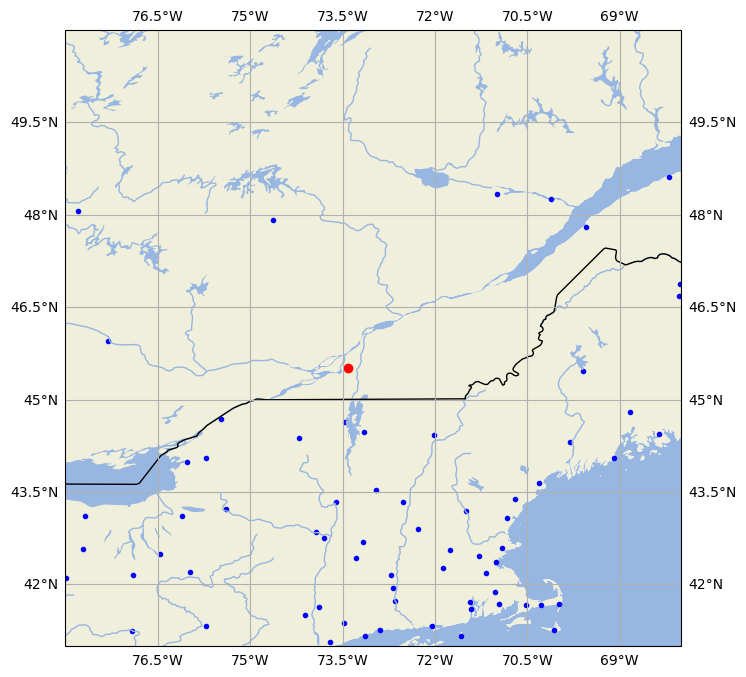

In [ ]:
# exemple de série temporelle pour un point

lat_pt =46
lon_pt = -73

# figure de la carte

da = ds_asos.sknt
dst2 = (da.lon - lon_pt)**2 + (da.lat-lat_pt)**2
ii_stat = dst2.argmin().values
da_pt = da.isel(station=ii_stat)

projection=ccrs.PlateCarree()

dlon = 5
dlat = 5
lllon = lon_pt - dlon
urlon = lon_pt + dlon
lllat = lat_pt - dlat
urlat = lat_pt + dlat

# on fait la figure
fig = plt.figure(figsize=(12, 8))
nx = 1
ny = 1
ax = fig.add_subplot(ny, nx, 1, projection=projection)
ax.set_extent([lllon, urlon, lllat, urlat], crs=projection)
# ax.set_extent([-85, -80, 40, 45], crs=projection)
# plt.scatter(-73,45, marker="*", color="red", s=100, label="Montreal")
plt.scatter(da.lon.values, da.lat.values, color="blue", marker=".")
plt.scatter(da_pt.lon.values, da_pt.lat.values, color="red", marker="o")

# details de la carte affichee
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.LAKES)
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.BORDERS)
ax.gridlines(draw_labels=True)
plt.show()
{'freq': 'YS', 'nb_periodes_minimum': 30, 'stations_valides': array(['ABE'], dtype=object)}



45.5167 -73.4167


<xarray.DataArray 'sknt' (time: 924533)> Size: 7MB
dask.array<getitem, shape=(924533,), dtype=float64, chunksize=(10000,), chunktype=numpy.ndarray>
Coordinates:
    country        object 8B dask.array<chunksize=(), meta=np.ndarray>
    elevation      float64 8B dask.array<chunksize=(), meta=np.ndarray>
    flag_doublons  int64 8B dask.array<chunksize=(), meta=np.ndarray>
    lat            float64 8B dask.array<chunksize=(), meta=np.ndarray>
    lon            float64 8B dask.array<chunksize=(), meta=np.ndarray>
    state          object 8B dask.array<chunksize=(), meta=np.ndarray>
    station        <U4 16B 'CYHU'
  * time           (time) datetime64[ns] 7MB 1901-01-01 ... 2025-09-11T21:00:00
Attributes:
    units:    kts

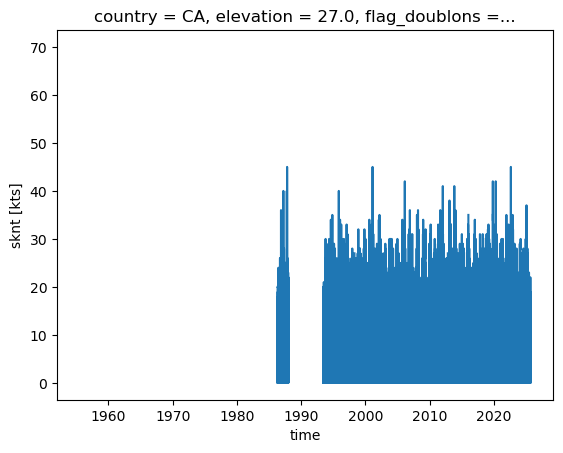

In [ ]:
# exemple de série temporelle pour un point

lat_pt =46
lon_pt = -73

# extraction de la station

da = ds_asos.sknt
dst2 = (da.lon - lon_pt)**2 + (da.lat-lat_pt)**2
ii_stat = dst2.argmin().values
da_pt = da.isel(station=ii_stat)
lon_stn = da_pt.lon.values
lat_stn = da_pt.lat.values
print(lat_stn, lon_stn)

da_pt.plot()

da_pt



In [ ]:
# comparaison station vs daf

from clisops.core.subset import subset_gridpoint
from xclim.core import units

# on masque car tres long a faire
if False:


    ds_daf = xr.open_mfdataset("/home/biner/exec/1_projets/202509_climato_vent/data/daf/series/*/sfcWind_*.nc")
    da_daf = ds_daf.sfcWind
    da_daf = units.convert_units_to(da_daf, "knot")


    da_daf_stn = subset_gridpoint(da_daf, lon=lon_stn, lat=lat_stn, start_date="1985")
    da_daf_stn

    da_pt.plot(label="asos")
    da_daf_stn.plot(label="daf")
    plt.show()

### triage des stations ASOS


In [20]:
# generation du mask de mois avec trop de données manquantes

da = ds_asos.sknt

#debug
# da = da.isel(station=range(10))
da.load()

print(da.count())

# conversion en moy quotidiennes
daq = da.resample(time="D").mean()
daq_cnt = da.resample(time="D").count()
daq = daq.where(daq_cnt==24)
print(daq_cnt.count())
print(daq.count())

# on genere un masque des mois incomplets
mask_wmo = xclim.core.missing.missing_wmo(daq, "MS")
mask_wmo

# sauvegarde des mois_incomplets pour éviter de refaire les test ensuite
p_mask_wmo_nc = f"mask_wmo_mois_incomplets_asos.nc"
mask_wmo.to_netcdf(p_mask_wmo_nc)
print(f"sauvegarde des mois incomplets des stations asos dans {p_mask_wmo_nc}")

# daq.isel(station=9).sel(time="1999-04").plot(marker=".")
# print(mask_wmo.isel(station=9).sel(time="1999-04").values)



<xarray.DataArray 'sknt' ()> Size: 8B
array(482531032)
<xarray.DataArray 'sknt' ()> Size: 8B
array(48915330)
<xarray.DataArray 'sknt' ()> Size: 8B
array(15056463)
sauvegarde des mois incomplets des stations asos dans mask_wmo_mois_incomplets_asos.nc


In [ ]:


# on regarde les stations qui repondent a certains critères
freq = "YS"
l_mois_periode = range(1, 13)
nb_mois_minimum_par_periodes = 12
nb_periodes_minimum = 20
nb_mois_valides_par_periode = (~mask_wmo.sel(time=mask_wmo.time.dt.month.isin(l_mois_periode))*1.).resample(time=freq).sum()
nb_periodes_valides = (nb_mois_valides_par_periode >= nb_mois_minimum_par_periodes).sum(dim="time")
stn_valides = nb_periodes_valides.where(nb_periodes_valides >= nb_periodes_minimum, drop=True).station
stn_valides
stn_rejets = da.where(~da.station.isin(stn_valides), drop=True).station
print(f"nb stations totales : {da.station.size}")
print(f"nb stations valides : {stn_valides.size}")
print(f"nb stations rejetees : {stn_rejets.size}")

# sauvegarde dans un fichier yaml
import yaml
d_sortie = dict(freq=freq, nb_periodes_minimum=nb_periodes_minimum, stations_valides=list(stn_valides.values))
p_yml = f"fichier_triage_wmo_stations_asos_{freq}_{nb_periodes_minimum}.yml"
print(f"ecriture de {p_yml}")
with open(p_yml, "w") as fh:
    yaml.dump(d_sortie, fh, allow_unicode=True)


# da_stn = da.sel(station=da.station.isin(stn_valides))
# da_stn.plot()


In [9]:
# filtrage des stations

da = ds_asos.sknt

# 



# on regarde les mois considérés comme incomplet selon le critère de la WMO
# *** prend beaucoup de temps ***
da = ds_asos.sknt

mask_wmo = xc.core.missing.missing_wmo(da, "MS")

KeyboardInterrupt: 

## donnees des mats HQ

In [6]:
# lecture des donnees 
f_mat = "/exec/biner/1_projets/202509_climato_vent/data/stations_mats_hq/traitees/data_mat_tous.nc"

ds_mat = xr.open_dataset(f_mat)

ds_mat

<xarray.Dataset> Size: 4GB
Dimensions:      (time: 157741, hauteur: 10, parc_mat: 65)
Coordinates:
  * time         (time) datetime64[ns] 1MB 2006-11-20T15:00:00 ... 2025-01-01
  * hauteur      (hauteur) float64 80B 40.0 50.0 60.0 70.0 ... 110.0 120.0 130.0
  * parc_mat     (parc_mat) <U8 2kB 'AAV_Mat1' 'AAV_Mat2' ... 'VEO_Mat1'
    parc         (parc_mat) <U3 780B ...
    mat          (parc_mat) <U6 2kB ...
    lat          (parc_mat) float64 520B ...
    lon          (parc_mat) float64 520B ...
Data variables:
    vent         (parc_mat, hauteur, time) float64 820MB ...
    temperature  (parc_mat, hauteur, time) float64 820MB ...
    pression     (parc_mat, hauteur, time) float64 820MB ...
    humidite     (parc_mat, hauteur, time) float64 820MB ...
    direction    (parc_mat, hauteur, time) float64 820MB ...

Text(0.5, 1.0, '65 stations mats HQ')

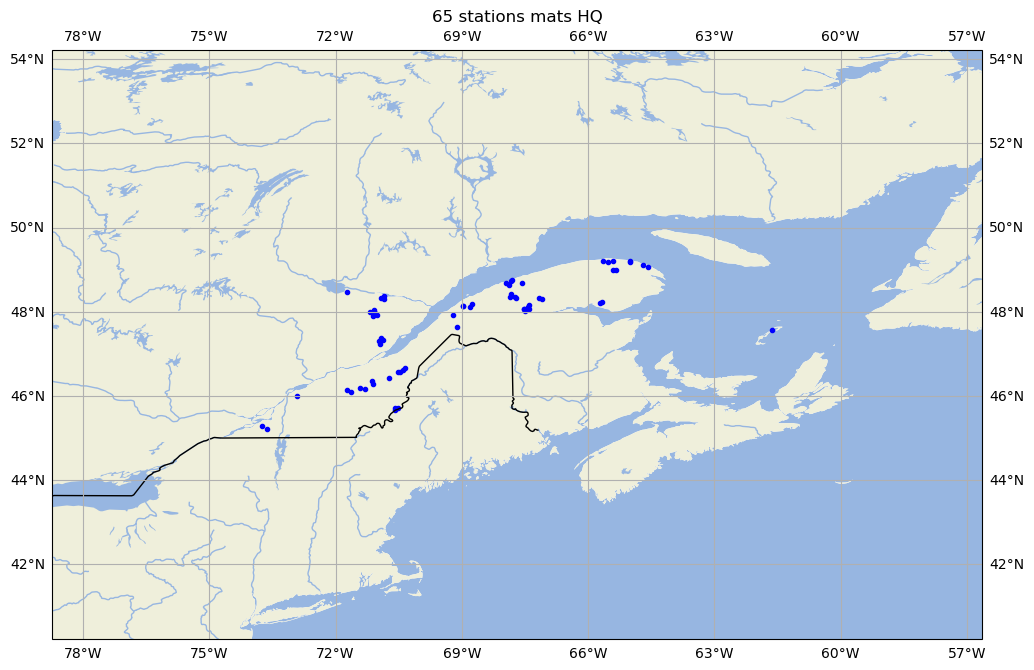

In [11]:
# affichage des positions des mats
da = ds_mat.vent

projection=ccrs.PlateCarree()

dlon = 5
dlat = 5
lllon = da.lon.min() - dlon
urlon = da.lon.max() + dlon
lllat = da.lat.min() - dlat
urlat = da.lat.max() + dlat

# on fait la figure
fig = plt.figure(figsize=(12, 8))
nx = 1
ny = 1
ax = fig.add_subplot(ny, nx, 1, projection=projection)
ax.set_extent([lllon, urlon, lllat, urlat], crs=projection)
# ax.set_extent([-85, -80, 40, 45], crs=projection)
# plt.scatter(-73,45, marker="*", color="red", s=100, label="Montreal")
plt.scatter(da.lon.values, da.lat.values, color="blue", marker=".")
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.LAKES)
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.BORDERS)
ax.gridlines(draw_labels=True)

titre = f"{da.parc_mat.size} stations mats HQ"
ax.set_title(titre)

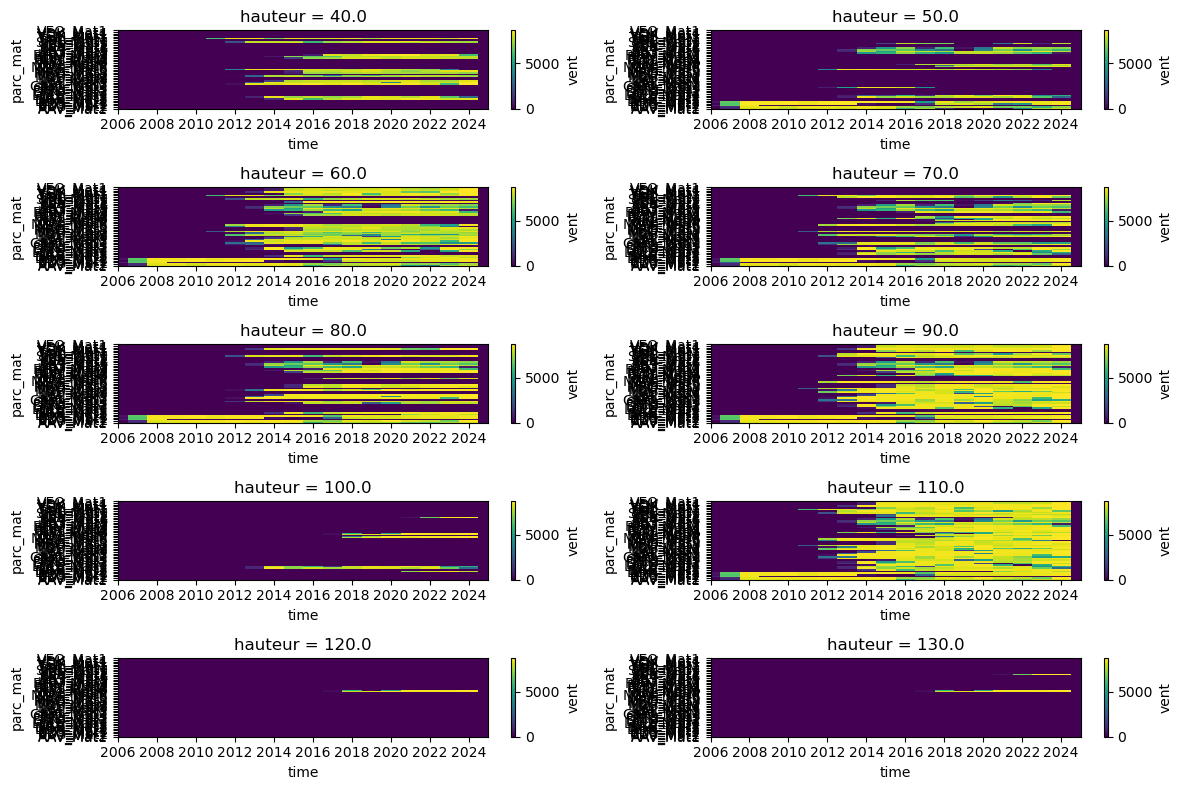

In [18]:
# affichage du nombre de données par année

cnt = da.resample(time="YS").count()
fig = plt.figure(figsize=(12, 8))
nx = 2
ny = 5
n_fig = 1
for hauteur in cnt.hauteur:
    ax = fig.add_subplot(ny, nx, n_fig)
    cnt_h = cnt.sel(hauteur=hauteur)
    cnt_h.plot(x="time")
    n_fig += 1
plt.tight_layout()
plt.show()

In [ ]:
## données d'ERA5-Land

rep_era5l = "/home/biner/exec/1_projets/202509_climato_vent/data/reconstruction_NAM/ECMWF/ERA5-Land"

# uas = xr.open_mfdataset(os.path.join(rep_era5l, "1hr", "uas", "uas_*zip" ))
# vas = xr.open_mfdataset(os.path.join(rep_era5l, "1hr", "vas", "vas_*zip" ))


rep_zarrzip = os.path.join(rep_era5l, "1hr", "uas", "uas_*.zarr.zip")
l_f = glob.glob(rep_zarrzip)
l_f.sort()
print(l_f)
print(len(l_f))
# l_f = l_f[:12]
l_ds = []
for ff in l_f:
    store = zarr.storage.ZipStore(ff, mode="r")
    ds = xr.open_dataset(store, engine="zarr")
    l_ds.append(ds)
# ds = xr.concat(l_ds, dim="time")
ds



# f_zarrzip = os.path.join(rep_era5l, "1hr", "uas", "uas_1hr_NAM_ECMWF_ERA5-Land_1950-1957.zarr.zip")
# store = zarr.storage.ZipStore(f_zarrzip, mode="r")
# ds = xr.open_dataset(store, engine="zarr")

# f_zarrzip_mf = os.path.join(rep_era5l, "1hr", "uas", "*.zip")
# store = zarr.storage.ZipStore(f_zarrzip_mf, mode="r")
# ds = xr.open_zarr(store_mf)
# ds



# vh = (uas ** 2 + vas ** 2)**0.5
#  

['/home/biner/exec/1_projets/202509_climato_vent/data/reconstruction_NAM/ECMWF/ERA5-Land/1hr/uas/uas_1hr_NAM_ECMWF_ERA5-Land_1950-1957.zarr.zip', '/home/biner/exec/1_projets/202509_climato_vent/data/reconstruction_NAM/ECMWF/ERA5-Land/1hr/uas/uas_1hr_NAM_ECMWF_ERA5-Land_1958-1965.zarr.zip', '/home/biner/exec/1_projets/202509_climato_vent/data/reconstruction_NAM/ECMWF/ERA5-Land/1hr/uas/uas_1hr_NAM_ECMWF_ERA5-Land_1966-1973.zarr.zip', '/home/biner/exec/1_projets/202509_climato_vent/data/reconstruction_NAM/ECMWF/ERA5-Land/1hr/uas/uas_1hr_NAM_ECMWF_ERA5-Land_1974-1981.zarr.zip', '/home/biner/exec/1_projets/202509_climato_vent/data/reconstruction_NAM/ECMWF/ERA5-Land/1hr/uas/uas_1hr_NAM_ECMWF_ERA5-Land_1982-1989.zarr.zip', '/home/biner/exec/1_projets/202509_climato_vent/data/reconstruction_NAM/ECMWF/ERA5-Land/1hr/uas/uas_1hr_NAM_ECMWF_ERA5-Land_1990-1997.zarr.zip', '/home/biner/exec/1_projets/202509_climato_vent/data/reconstruction_NAM/ECMWF/ERA5-Land/1hr/uas/uas_1hr_NAM_ECMWF_ERA5-Land_1998-

<xarray.Dataset> Size: 32GB
Dimensions:  (lat: 801, lon: 1700, time: 5832)
Coordinates:
  * lat      (lat) float32 3kB 10.0 10.1 10.2 10.3 10.4 ... 89.7 89.8 89.9 90.0
  * lon      (lon) float32 7kB -179.9 -179.8 -179.7 -179.6 ... -10.2 -10.1 -10.0
  * time     (time) datetime64[ns] 47kB 2025-01-01 ... 2025-08-31T23:00:00
Data variables:
    uas      (time, lat, lon) float32 32GB ...
Attributes: (12/15)
    Conventions:             CF-1.8
    doi:                     https://doi.org/10.24381/cds.e2161bac
    domain:                  NAM
    format:                  zarr
    frequency:               1hr
    institution:             ECMWF
    ...                      ...
    license:                 https://apps.ecmwf.int/datasets/licences/coperni...
    processing_level:        raw
    project:                 era5-land
    realm:                   atmos
    source:                  ERA5-Land
    type:                    reconstruction

In [ ]:
# lecture

## données du MRCC

In [ ]:
rep_daf = "/home/biner/exec/1_projets/202509_climato_vent/data/data_olivier/diagnostics_exact/daf/100m"

rep_h = os.path.join(rep_dat, "hourly")
rep_moy_mens = os.path.join(rep_dat, "monthly_means")



 